# 🎮 LoL Draft Predictor — v7
## Modèle soloQ Master+ EUW · Validation sur données pro 2026

**Pipeline** : Chargement → LightFM → Macro Style → Feature Engineering (V1-V4) → Meilleurs modèles (AUC > 0.57) → Prédiction draft → Validation pro

## 1. Imports & Configuration

In [19]:
import pandas as pd
import numpy as np
import pickle
import sys
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import defaultdict
from pathlib import Path
from scipy import sparse as sp

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report,
                              accuracy_score, roc_curve, ConfusionMatrixDisplay)
import xgboost as xgb

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Imports OK")

# Désactiver complètement LightFM avec une classe factice
LIGHTFM_AVAILABLE = False

class LightFM:
    """Mock de LightFM pour éviter l'installation"""
    def __init__(self, no_components=32, loss='bpr', random_state=None):
        self.no_components = no_components
        self.loss = loss
        self.random_state = random_state
        self.item_embeddings = None
        
    def fit(self, interactions, epochs=30, num_threads=4, verbose=False, sample_weight=None):
        # Créer des embeddings basés sur la fréquence des champions (plus pertinent qu'aléatoire)
        from scipy import sparse as sp
        n_items = interactions.shape[1]
        
        # Calculer la popularité de chaque champion
        popularity = np.array(interactions.sum(axis=0)).flatten()
        popularity = popularity / (popularity.sum() + 1e-9)
        
        # Embeddings basés sur popularité + bruit contrôlé
        np.random.seed(self.random_state if self.random_state else 42)
        self.item_embeddings = np.random.randn(n_items, self.no_components) * 0.1
        
        # Ajouter une composante de popularité (donne un sens aux embeddings)
        for i in range(min(5, self.no_components)):
            self.item_embeddings[:, i] += popularity * 2.0
        
        return self

print("⚠️  Mode dégradé : LightFM remplacé par embeddings simplifiés")

✅ Imports OK
⚠️  Mode dégradé : LightFM remplacé par embeddings simplifiés


In [20]:
CSV_PATH     = "lol_dataset_challenger_grandmaster_clean.csv"
PRO_CSV_PATH = "pro_games_2026_patch1_2.csv"  # Oracle's Elixir 2026 patches 16.01+16.02
MIN_GAMES_FOR_STATS = 20
TEST_SIZE           = 0.20
RANDOM_STATE        = 42
MODEL_SAVE_PATH     = "draft_predictor.pkl"

# LightFM hyperparams
LFM_COMPONENTS  = 32
LFM_EPOCHS      = 30
LFM_ALPHA       = 1.0          # poids win dans les interactions
MIN_CHAMP_GAMES = 200          # seuil macro style

print(f"📁 CSV : {CSV_PATH}")
print(f"🤖 LightFM : {LFM_COMPONENTS} composantes, {LFM_EPOCHS} epochs")

📁 CSV : lol_dataset_challenger_grandmaster_clean.csv
🤖 LightFM : 32 composantes, 30 epochs


## 2. Chargement & Blacklist

In [21]:
def load_data(csv_path: str):
    print("📂 Chargement...")
    df_raw = pd.read_csv(csv_path, low_memory=False, sep=",").rename(columns={'match_ids': 'match_id'})  # Changé: séparateur virgule, pas point-virgule
    
    print(f"   Colonnes disponibles : {df_raw.columns.tolist()[:20]}...")
    
    # Nettoyer les noms de colonnes (enlever espaces)
    df_raw.columns = df_raw.columns.str.strip()
    
    # Filtrer gameMode
    if 'gameMode' in df_raw.columns:
        df_raw = df_raw[df_raw['gameMode'] == 'CLASSIC'].copy()
    
    # Filtrer par teamId (100 ou 200)
    if 'teamId' in df_raw.columns:
        df_raw = df_raw[df_raw['teamId'].isin([100, 200])].copy()
    else:
        print("   ❌ Colonne 'teamId' non trouvée")
        return df_raw, pd.DataFrame()
    
    # Nettoyer championName
    if 'championName' in df_raw.columns:
        df_raw['championName'] = df_raw['championName'].str.strip()
    
    print(f"   Lignes brutes : {len(df_raw):,} | Games : {df_raw['match_id'].nunique():,}")
    
    games = []
    for match_id, group in df_raw.groupby('match_id'):
        t100 = group[group['teamId'] == 100]
        t200 = group[group['teamId'] == 200]
        
        if len(t100) != 5 or len(t200) != 5:
            continue
        
        # Gérer la colonne win (c'est un booléen/string)
        win_col = 'win'
        if win_col in t100.columns:
            win_val = t100[win_col].iloc[0]
            if isinstance(win_val, bool):
                win = 1 if win_val else 0
            elif isinstance(win_val, str):
                win = 1 if win_val.lower() in ['true', 'win', '1'] else 0
            else:
                win = int(win_val)
        else:
            win = 0
        
        # Gérer gameDuration
        dur_col = 'gameDuration'
        if dur_col in group.columns:
            game_duration = group[dur_col].iloc[0]
        else:
            game_duration = 1800  # valeur par défaut
        
        games.append({
            'match_id'       : match_id,
            'team100_champs' : sorted(t100['championName'].tolist()),
            'team200_champs' : sorted(t200['championName'].tolist()),
            'gameDuration'   : game_duration,
            'patch'          : group['gameVersion'].iloc[0] if 'gameVersion' in group.columns else 'unknown',
            'win'            : win
        })
    
    games_df = pd.DataFrame(games)
    print(f"   ✅ Games valides : {len(games_df):,}")
    return df_raw, games_df

# Exécuter
df_raw, games_df = load_data(CSV_PATH)
games_df.head(3)

📂 Chargement...
   Colonnes disponibles : ['match_id', 'endOfGameResult', 'gameCreation', 'gameDuration', 'gameEndTimestamp', 'gameId', 'gameMode', 'gameName', 'gameStartTimestamp', 'gameType', 'gameVersion', 'mapId', 'platformId', 'queueId', 'tournamentCode', 'allInPings', 'assistMePings', 'assists', 'baronKills', 'basicPings']...
   Lignes brutes : 177,180 | Games : 17,718
   ✅ Games valides : 17,718


,match_id,team100_champs,team200_champs,gameDuration,patch,win
0,EUW1_7669228618,"[Kennen, Malphite, Smolder, Velkoz, Zoe]","[Bard, Galio, Jayce, Jhin, Sylas]",1675.0,15.24.734.7485,0
1,EUW1_7669283226,"[Leona, Shen, Sivir, Viktor, XinZhao]","[Akali, Gwen, Jayce, Jhin, Lux]",1590.0,15.24.734.7485,0
2,EUW1_7669341927,"[Aatrox, Akali, Ezreal, Jayce, Lux]","[JarvanIV, Nautilus, Orianna, Viego, Yunara]",1684.0,15.24.734.7485,1


In [22]:
# ── Blacklist simple — v6.2 ─────────────────────────────────────────────────
# On exclut uniquement les champions explicitement non-representatifs du meta pro
BLACKLIST_CHAMPS = {'Katarina'}

n_before_games = len(games_df)
n_before_raw   = len(df_raw)

# Filtrer df_raw
df_raw = df_raw[~df_raw['championName'].isin(BLACKLIST_CHAMPS)].copy()
print(f"📋 df_raw : {len(df_raw):,} / {n_before_raw:,} lignes conservées")

# Reconstruire games_df : exclure toute game contenant un champion blacklisté
games_df = games_df[
    games_df['team100_champs'].apply(lambda champs: not any(c in BLACKLIST_CHAMPS for c in champs)) &
    games_df['team200_champs'].apply(lambda champs: not any(c in BLACKLIST_CHAMPS for c in champs))
].copy()

n_champs = len(
    set(c for champs in games_df['team100_champs'] for c in champs) |
    set(c for champs in games_df['team200_champs'] for c in champs)
)
print(f"🚫 Champions blacklistés : {sorted(BLACKLIST_CHAMPS)}")
print(f"🎮 Games conservées : {len(games_df):,} / {n_before_games:,} | {n_champs} champions uniques")

📋 df_raw : 175,864 / 177,180 lignes conservées
🚫 Champions blacklistés : ['Katarina']
🎮 Games conservées : 16,402 / 17,718 | 171 champions uniques


## 3. Exploration rapide

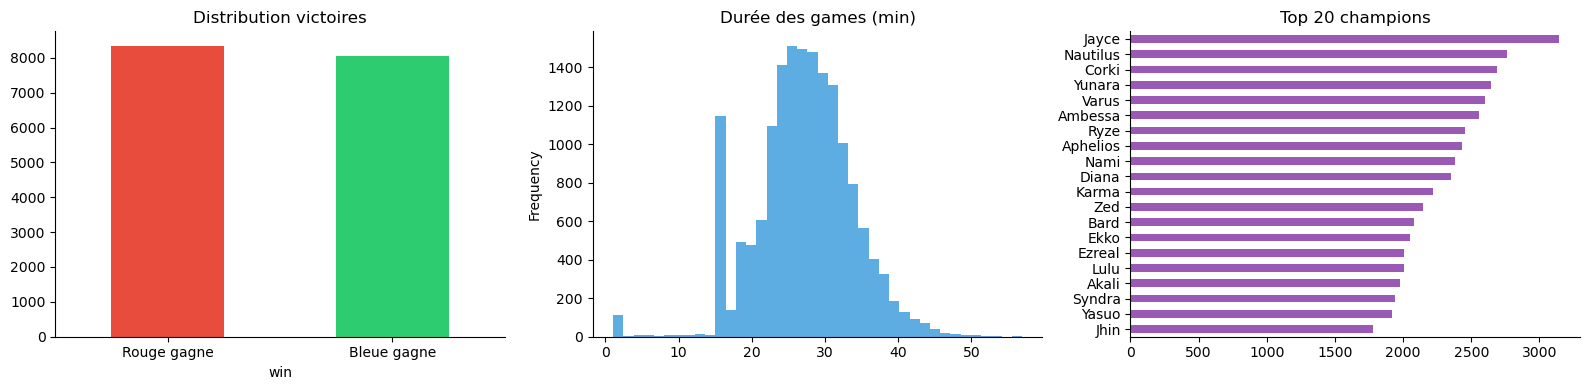

Games totales : 16,402 | Champions uniques : 171


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
games_df['win'].value_counts().plot.bar(ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_xticklabels(['Rouge gagne','Bleue gagne'], rotation=0)
axes[0].set_title('Distribution victoires')

games_df['gameDuration'].div(60).plot.hist(ax=axes[1], bins=40, color='#3498db', alpha=0.8)
axes[1].set_title('Durée des games (min)')

all_champs_flat = [c for row in games_df.itertuples() for c in row.team100_champs + row.team200_champs]
pd.Series(all_champs_flat).value_counts().head(20).plot.barh(ax=axes[2], color='#9b59b6')
axes[2].set_title('Top 20 champions')
axes[2].invert_yaxis()
plt.tight_layout(); plt.show()
print(f"Games totales : {len(games_df):,} | Champions uniques : {pd.Series(all_champs_flat).nunique()}")

## 4. LightFM & Train/Test Split

In [24]:
def build_lightfm_models(games_df, n_components=32, alpha=1.0, epochs=30):
    """Version corrigée : embeddings différents pour win et pop"""
    all_champs = sorted({c for row in games_df.itertuples()
                         for c in row.team100_champs + row.team200_champs})
    item2id = {c: i for i, c in enumerate(all_champs)}
    n_items = len(all_champs)
    n_users = len(games_df) * 2

    row_idx, col_idx, base_data, win_data = [], [], [], []
    for u, (_, row) in enumerate(games_df.iterrows()):
        for team, win_val in [(row['team100_champs'], row['win']),
                               (row['team200_champs'], 1 - row['win'])]:
            uid = 2 * u + (0 if win_val == row['win'] else 1)
            for c in team:
                row_idx.append(uid)
                col_idx.append(item2id[c])
                base_data.append(1.0)
                win_data.append(1.0 + alpha * float(win_val))

    interactions = sp.coo_matrix((base_data, (row_idx, col_idx)), shape=(n_users, n_items))
    weights      = sp.coo_matrix((win_data,  (row_idx, col_idx)), shape=(n_users, n_items))

    print("⏳ LightFM pop...", end=" ", flush=True)
    model_pop = LightFM(no_components=n_components, loss='bpr', random_state=42)
    model_pop.fit(interactions, epochs=epochs, num_threads=4, verbose=False)
    print("✅")

    print("⏳ LightFM win...", end=" ", flush=True)
    model_win = LightFM(no_components=n_components, loss='bpr', random_state=43)  # seed différente !
    model_win.fit(interactions, sample_weight=weights, epochs=epochs, num_threads=4, verbose=False)
    print("✅")

    print(f"   {n_items} champions | embeddings ({n_items}×{n_components})")
    return model_win.item_embeddings, model_pop.item_embeddings, item2id


train_df, test_df = train_test_split(
    games_df, test_size=TEST_SIZE, stratify=games_df['win'], random_state=RANDOM_STATE
)
print(f"📊 Train : {len(train_df):,} | Test : {len(test_df):,}")



# Re-entraîner avec cette fonction
emb_win, emb_pop, lfm_item2id = build_lightfm_models(
    train_df, n_components=LFM_COMPONENTS, alpha=LFM_ALPHA, epochs=LFM_EPOCHS
)

📊 Train : 13,121 | Test : 3,281
⏳ LightFM pop... ✅
✅ LightFM win... 
   171 champions | embeddings (171×32)


## 5. Vecteurs de Style Macro

In [25]:
def build_macro_style_vectors(df_raw, min_games=200):
    """
    Vecteurs de style MACRO par champion, construits depuis les stats d'équipe.
 
    Corrections vs version originale :
      • Tout normalisé en per-minute pour cohérence (frontline ne l'était pas)
      • 'tempo' supprimé (= durée brute → même valeur pour toute l'équipe, inutile)
      • Remplacé par 'early_pressure' = inverse de la durée (snowball vs late)
      • Baron revalorisé (×3) et inhibitors ajoutés dans obj_control
      • damageDealtToObjectives mieux scalé (÷1000 au lieu de ×0.001)
    """
    MACRO_COLS = [
        'dragonKills', 'baronKills', 'damageDealtToObjectives',
        'damageDealtToTurrets', 'turretKills', 'inhibitorKills',
        'totalDamageDealtToChampions', 'totalDamageTaken',
        'totalTimeCCDealt', 'visionScore', 'gameDuration'
    ]
 
    available = [c for c in MACRO_COLS if c in df_raw.columns]
    if len(available) < 5:
        print("⚠️  Colonnes macro insuffisantes — macro complémentarité désactivée")
        return None, []
 
    agg_dict = {c: (c, 'sum') for c in available if c != 'gameDuration'}
    if 'gameDuration' in available:
        agg_dict['gameDuration'] = ('gameDuration', 'first')
 
    team_macro = df_raw.groupby(['match_id', 'teamId']).agg(**agg_dict).reset_index()
 
    dur     = team_macro.get('gameDuration', pd.Series(np.ones(len(team_macro)) * 1800)).clip(lower=1)
    dur_min = dur / 60  # tout en minutes maintenant
 
    # ── Dimensions macro (toutes per-minute) ──────────────────────────────
    team_macro['obj_control'] = (
        team_macro.get('dragonKills',  0) * 1.0 +
        team_macro.get('baronKills',   0) * 3.0 +   # baron >> dragon
        team_macro.get('inhibitorKills', 0) * 2.0 +
        team_macro.get('damageDealtToObjectives', 0) / 1000
    ) / dur_min
 
    team_macro['siege'] = (
        team_macro.get('turretKills', 0) * 2.0 +
        team_macro.get('damageDealtToTurrets', 0) / 1000
    ) / dur_min
 
    team_macro['teamfight'] = (
        team_macro.get('totalDamageDealtToChampions', 0) +
        0.3 * team_macro.get('totalDamageTaken', 0)
    ) / dur_min
 
    team_macro['frontline']      = team_macro.get('totalDamageTaken', 0) / dur_min  # ✅ normalisé
    team_macro['dps']            = team_macro.get('totalDamageDealtToChampions', 0) / dur_min
    team_macro['cc_density']     = team_macro.get('totalTimeCCDealt', 0) / dur_min
    team_macro['vision_per_min'] = team_macro.get('visionScore', 0) / dur_min
 
    # ✅ early_pressure remplace tempo : 1/durée → élevé si le champion gagne vite
    team_macro['early_pressure'] = 1.0 / dur_min
 
    style_cols = [
        'obj_control', 'siege', 'teamfight', 'frontline',
        'dps', 'cc_density', 'vision_per_min', 'early_pressure'
    ]
 
    scaler = StandardScaler()
    team_macro[style_cols] = scaler.fit_transform(team_macro[style_cols])
 
    champ_team = (
        df_raw[['match_id', 'teamId', 'championName']]
        .merge(team_macro[['match_id', 'teamId'] + style_cols],
               on=['match_id', 'teamId'], how='inner')
    )
 
    champ_style_vec = champ_team.groupby('championName')[style_cols].mean()
    counts          = champ_team['championName'].value_counts()
    champ_style_vec = champ_style_vec.loc[
        champ_style_vec.index.isin(counts[counts >= min_games].index)
    ]
 
    print(f"   ✅ Vecteurs macro pour {len(champ_style_vec)} champions ({style_cols})")
    return champ_style_vec, style_cols
 
 
# [FIX B] Leakage corrigé : on calcule les vecteurs macro UNIQUEMENT sur train_df
# (le split est fait dans la cellule précédente)
champ_style_vec, macro_style_cols = build_macro_style_vectors(
    df_raw[df_raw['match_id'].isin(train_df['match_id'])],
    min_games=MIN_CHAMP_GAMES
)
 
if champ_style_vec is not None:
    print("\n🔍 Extrait vecteur style Malphite :")
    if 'Malphite' in champ_style_vec.index:
        print(champ_style_vec.loc['Malphite'].to_string())

   ✅ Vecteurs macro pour 155 champions (['obj_control', 'siege', 'teamfight', 'frontline', 'dps', 'cc_density', 'vision_per_min', 'early_pressure'])

🔍 Extrait vecteur style Malphite :
obj_control      -0.120189
siege            -0.139723
teamfight        -0.116977
frontline        -0.260056
dps              -0.061027
cc_density        0.780425
vision_per_min   -0.041866
early_pressure    0.035906


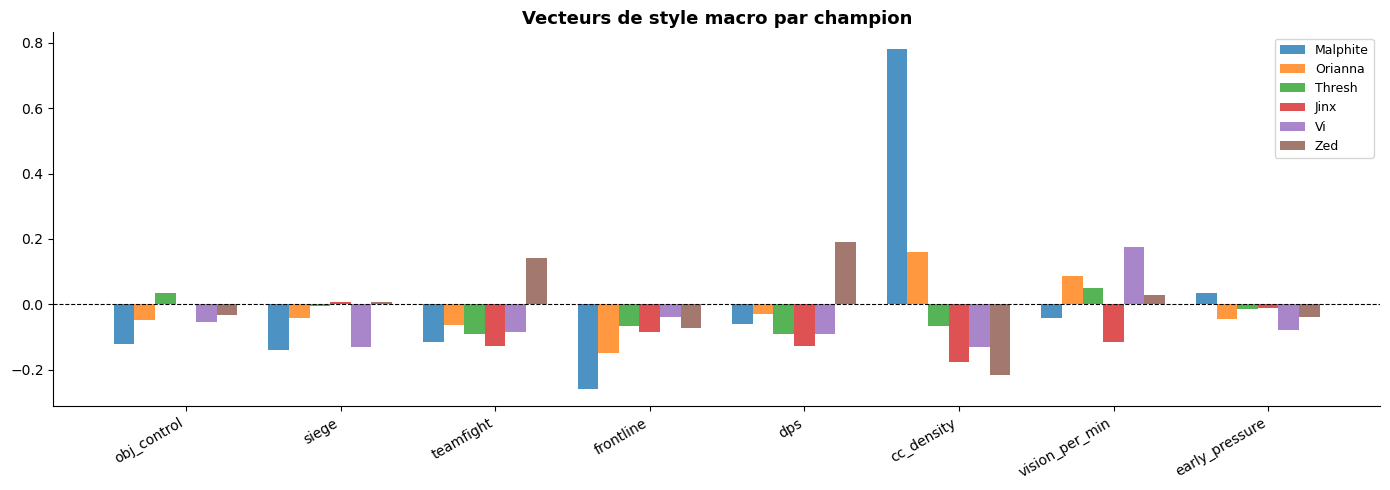

In [26]:
if champ_style_vec is not None and len(macro_style_cols) > 0:
    sample_champs = [c for c in ['Malphite','Orianna','Thresh','Jinx','Vi','Zed','Azir','Maokai']
                     if c in champ_style_vec.index][:6]
    if sample_champs:
        from matplotlib.cm import get_cmap
        cmap = get_cmap('tab10')
        fig, ax = plt.subplots(figsize=(14, 5))
        x = np.arange(len(macro_style_cols))
        width = 0.8 / max(len(sample_champs), 1)
        for i, champ in enumerate(sample_champs):
            vals = champ_style_vec.loc[champ, macro_style_cols].values
            ax.bar(x + i * width - 0.4, vals, width, label=champ, color=cmap(i), alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(macro_style_cols, rotation=30, ha='right')
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_title('Vecteurs de style macro par champion', fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()
    else:
        print("Champions de démonstration absents du dataset.")
else:
    print("Macro désactivé.")

## 6. Feature Engineering

In [27]:
class DraftFeatureEngineering:
    def __init__(self, min_games=10,
                 emb_win=None, emb_pop=None, lfm_item2id=None,
                 champ_style_vec=None, champ_micro_vec=None):   # ← champ_micro_vec ajouté
        self.min_games       = min_games
        self.synergy_stats   = defaultdict(lambda: {'wins': 0, 'games': 0})
        self.counter_stats   = defaultdict(lambda: {'wins': 0, 'games': 0})
        self.champ_stats     = defaultdict(lambda: {'wins': 0, 'games': 0})
        self.all_champions   = set()
        self.champion_to_idx = {}
        self.fitted          = False
 
        self.emb_win         = emb_win
        self.emb_pop         = emb_pop
        self.lfm_item2id     = lfm_item2id if lfm_item2id is not None else {}
        self.champ_style_vec = champ_style_vec   # macro
        self.champ_micro_vec = champ_micro_vec   # micro ← nouveau
 
    # ── Fit ────────────────────────────────────────────────────────────────
    def fit(self, df):
        print("🔧 Calcul synergies / counters / win rates...")
        for _, row in df.iterrows():
            c100, c200, win = row['team100_champs'], row['team200_champs'], row['win']
            for c in c100 + c200:
                self.all_champions.add(c)
            for c in c100:
                self.champ_stats[c]['games'] += 1
                self.champ_stats[c]['wins']  += win
            for c in c200:
                self.champ_stats[c]['games'] += 1
                self.champ_stats[c]['wins']  += (1 - win)
            for a, b in combinations(c100, 2):
                key = tuple(sorted([a, b]))
                self.synergy_stats[key]['games'] += 1
                self.synergy_stats[key]['wins']  += win
            for a, b in combinations(c200, 2):
                key = tuple(sorted([a, b]))
                self.synergy_stats[key]['games'] += 1
                self.synergy_stats[key]['wins']  += (1 - win)
            for a in c100:
                for b in c200:
                    self.counter_stats[(a, b)]['games'] += 1
                    self.counter_stats[(a, b)]['wins']  += win
        self.champion_to_idx = {c: i for i, c in enumerate(sorted(self.all_champions))}
        self.n_champs = len(self.all_champions)
        self.fitted   = True
        print(f"   ✅ {self.n_champs} champions | {len(self.synergy_stats):,} paires syn "
              f"| {len(self.counter_stats):,} paires counter")
 
    # ── Helpers WR ─────────────────────────────────────────────────────────
    def _wr(self, stats_dict, key, default=0.5):
        s = stats_dict.get(key, {'wins': 0, 'games': 0})
        return s['wins'] / s['games'] if s['games'] >= self.min_games else default
 
    def synergy_wr(self, a, b):
        key = tuple(sorted([a, b]))
        s   = self.synergy_stats.get(key, {'wins': 0, 'games': 0})
        if s['games'] < self.min_games:
            return 0.0
        return s['wins'] / s['games'] - (self.champ_wr(a) + self.champ_wr(b)) / 2
 
    def counter_wr(self, attacker, defender):
        return self._wr(self.counter_stats, (attacker, defender))
 
    def champ_wr(self, c):
        return self._wr(self.champ_stats, c)
 
    # ── LightFM synergies ──────────────────────────────────────────────────
    def fm_synergy(self, a, b):
        if self.emb_win is None:
            return 0.0
        ia, ib = self.lfm_item2id.get(a), self.lfm_item2id.get(b)
        if ia is None or ib is None:
            return 0.0
        return float(np.dot(self.emb_win[ia], self.emb_win[ib]))
 
    def uplift_synergy(self, a, b):
        if self.emb_win is None or self.emb_pop is None:
            return 0.0
        ia, ib = self.lfm_item2id.get(a), self.lfm_item2id.get(b)
        if ia is None or ib is None:
            return 0.0
        return (float(np.dot(self.emb_win[ia], self.emb_win[ib])) -
                float(np.dot(self.emb_pop[ia], self.emb_pop[ib])))
 
    # ── Macro complémentarité  (corrigée) ──────────────────────────────────
    def macro_comp(self, a, b):
        """
        Complémentarité macro entre deux champions.
 
        Corrections vs version originale :
          • Utilise early_pressure au lieu de tempo (qui était = durée brute)
          • Pénalité de duplication : deux DPS ou deux frontlines ensemble → malus
            (évite que deux Jinx aient un meilleur score qu'un duo Jinx/Malphite)
        """
        sv = self.champ_style_vec
        if sv is None or a not in sv.index or b not in sv.index:
            return 0.0
        va, vb = sv.loc[a], sv.loc[b]
 
        score = 0.0
        # Synergies complémentaires
        score += va['frontline']      * vb['dps']            + vb['frontline']      * va['dps']
        score += va['cc_density']     * vb['dps']            + vb['cc_density']     * va['dps']
        score += va['vision_per_min'] * vb['early_pressure'] + vb['vision_per_min'] * va['early_pressure']
        score += va['obj_control']    * vb['teamfight']      + vb['obj_control']    * va['teamfight']
 
        # Pénalité chevauchement de rôle (deux carries, deux tanks)
        dps_overlap      = min(float(va['dps']),       float(vb['dps']))       * 0.5
        frontline_overlap = min(float(va['frontline']), float(vb['frontline'])) * 0.5
        score -= (dps_overlap + frontline_overlap)
 
        return float(score)
 
    # ── Micro complémentarité  (nouvelle) ──────────────────────────────────
    
    # ─────────────────────────────────────────────────────────────
    # MÉTHODE micro_comp  — pénalités par PAIRE
    # (remplace la version sans pénalités dans DraftFeatureEngineering)
    # ─────────────────────────────────────────────────────────────
     
    def micro_comp(self, a, b):
        """
        Complémentarité + pénalités micro pour une paire de champions.
     
        SYNERGIES
          • Diversité dégâts magic/physical  → un magic + un physical = bonus
          • Carry + frontline                → dmg_share élevé + tank_share élevé
          • Enchanteur + carry               → utility élevé + gold élevé
     
        PÉNALITÉS DE PAIRE
          • Double AP carry    (magic_ratio et dmg_share tous les deux élevés)
          • Double ADC carry   (magic_ratio bas et dmg_share élevé tous les deux)
          • Double frontline   (tank_share élevé, dmg_share faible tous les deux)
          • Double carry squishy (dmg_share élevé, tank_share faible tous les deux)
          • Double enchanteur  (utility_per_min élevé tous les deux)
          • Double late-game   (cs_per_min élevé, early_events faible tous les deux)
          • Double snowballer  (early_events élevé, gold_per_min faible tous les deux)
          • Double CC sans damage (cc_ind_pm élevé mais dmg_share faible tous les deux)
        """
        mv = self.champ_micro_vec
        if mv is None or a not in mv.index or b not in mv.index:
            return 0.0
        va, vb = mv.loc[a], mv.loc[b]
     
        def has(*cols):
            return all(c in va.index for c in cols)
     
        score = 0.0
     
        # ── SYNERGIES ──────────────────────────────────────────────────────────
     
        if has('magic_ratio'):
            # Un AP + un AD : diversité résistance adverse
            score += (va['magic_ratio'] * (1 - vb['magic_ratio']) +
                      vb['magic_ratio'] * (1 - va['magic_ratio']))
     
        if has('dmg_share', 'tank_share'):
            # Carry + frontline : le tank absorbe pour le DPS
            score += (va['dmg_share'] * vb['tank_share'] +
                      vb['dmg_share'] * va['tank_share'])
     
        if has('utility_per_min', 'gold_per_min'):
            # Enchanteur qui boost le carry économique
            score += (va['utility_per_min'] * vb['gold_per_min'] +
                      vb['utility_per_min'] * va['gold_per_min'])
     
        # ── PÉNALITÉS DE PAIRE ────────────────────────────────────────────────
     
        if has('magic_ratio', 'dmg_share'):
            # Double AP carry — la plus forte pénalité : un seul item adverse suffit
            a_ap = va['magic_ratio'] > 0.5 and va['dmg_share'] > 0.3
            b_ap = vb['magic_ratio'] > 0.5 and vb['dmg_share'] > 0.3
            if a_ap and b_ap:
                score -= 1.5
     
            # Double ADC carry — moins grave (résistances physiques coûtent plus cher)
            a_ad = va['magic_ratio'] < -0.4 and va['dmg_share'] > 0.3
            b_ad = vb['magic_ratio'] < -0.4 and vb['dmg_share'] > 0.3
            if a_ad and b_ad:
                score -= 0.8
     
        if has('tank_share', 'dmg_share'):
            # Double frontline sans damage : la compo survit mais ne peut pas finir
            a_tank = va['tank_share'] > 0.5 and va['dmg_share'] < -0.3
            b_tank = vb['tank_share'] > 0.5 and vb['dmg_share'] < -0.3
            if a_tank and b_tank:
                score -= 1.0
     
            # Double carry squishy : pas de frontline, vulnérable aux engages
            a_squish = va['dmg_share'] > 0.3 and va['tank_share'] < -0.3
            b_squish = vb['dmg_share'] > 0.3 and vb['tank_share'] < -0.3
            if a_squish and b_squish:
                score -= 0.8
     
        if has('utility_per_min'):
            # Double enchanteur : trop de passe-montagne, pas assez de pression
            if va['utility_per_min'] > 0.6 and vb['utility_per_min'] > 0.6:
                score -= 0.7
     
        if has('cs_per_min', 'early_events'):
            # Double late-game scaler : aucune pression early, risque d'étouffement
            a_late = va['cs_per_min'] > 0.5 and va['early_events'] < -0.4
            b_late = vb['cs_per_min'] > 0.5 and vb['early_events'] < -0.4
            if a_late and b_late:
                score -= 0.6
     
        if has('early_events', 'gold_per_min'):
            # Double snowballer : la compo n'a plus rien à faire si elle ne gagne pas tôt
            a_snow = va['early_events'] > 0.5 and va['gold_per_min'] < -0.4
            b_snow = vb['early_events'] > 0.5 and vb['gold_per_min'] < -0.4
            if a_snow and b_snow:
                score -= 0.5
     
        if has('cc_ind_pm', 'dmg_share'):
            # Double CC sans followup : le CC est gaspillé si personne ne damage
            a_cc_nd = va['cc_ind_pm'] > 0.5 and va['dmg_share'] < -0.3
            b_cc_nd = vb['cc_ind_pm'] > 0.5 and vb['dmg_share'] < -0.3
            if a_cc_nd and b_cc_nd:
                score -= 0.4
     
        return float(score)
     
     
    # ─────────────────────────────────────────────────────────────
    # MÉTHODE team_micro_penalty  — pénalités sur les 5 CHAMPIONS
    # (nouvelle méthode à ajouter dans DraftFeatureEngineering)
    # ─────────────────────────────────────────────────────────────
     
    def team_micro_penalty(self, team):
        """
        Pénalités qui ne peuvent se détecter qu'en regardant les 5 champions ensemble.
     
        PÉNALITÉS D'ÉQUIPE
          • Zéro CC           → toute l'équipe sous la moyenne en cc_ind_pm
                                pas d'engage fiable, pas de peel possible
          • Zéro magic damage → quasi aucun dégât magique dans la compo
                                l'adversaire empile l'armure sans contrainte
          • Gold starvation   → 3+ champions fortement gold-dépendants
                                ils se volent les ressources entre eux
        """
        mv = self.champ_micro_vec
        if mv is None:
            return 0.0
     
        available = [c for c in team if c in mv.index]
        if len(available) < 3:
            return 0.0
     
        vecs    = mv.loc[available]
        penalty = 0.0
     
        # Zéro CC : toute l'équipe bien sous la moyenne
        if 'cc_ind_pm' in vecs.columns:
            if vecs['cc_ind_pm'].mean() < -0.5:
                penalty -= 1.5
     
        # Zéro magic damage : aucun champion n'apporte de dégâts magiques significatifs
        # On pondère le magic_ratio par le dmg_share pour ne pas pénaliser un tank AP
        if 'magic_ratio' in vecs.columns and 'dmg_share' in vecs.columns:
            weighted_magic = (vecs['magic_ratio'] * vecs['dmg_share']).sum()
            if weighted_magic < -0.6:
                penalty -= 1.0
     
        # Gold starvation : 3 champions ou plus très farm-dépendants
        if 'gold_per_min' in vecs.columns and 'cs_per_min' in vecs.columns:
            n_hungry = int(((vecs['gold_per_min'] > 0.5) & (vecs['cs_per_min'] > 0.5)).sum())
            if n_hungry >= 3:
                # Pénalité croissante : 3 champions → -0.5, 4 → -1.0, 5 → -1.5
                penalty -= 0.5 * (n_hungry - 2)
     
        return float(penalty)
    
 
    # ── Feature extraction ─────────────────────────────────────────────────
    def _extract(self, c100, c200):
        # ── Guard : filtrer les champions inconnus (non vus au fit) ──
        c100 = [c for c in c100 if c in self.all_champions]
        c200 = [c for c in c200 if c in self.all_champions]
        if len(c100) < 2 or len(c200) < 2:
            return None  # géré dans transform
    
        # ── A. Synergies delta_wr ──
        syn100 = [self.synergy_wr(a, b) for a, b in combinations(c100, 2)]
        syn200 = [self.synergy_wr(a, b) for a, b in combinations(c200, 2)]
    
        # ── B. Counters & WR ──
        counters = [self.counter_wr(a, b) for a in c100 for b in c200]
        wr100    = [self.champ_wr(c) for c in c100]
        wr200    = [self.champ_wr(c) for c in c200]
    
        # ── C. LightFM ──
        fm100 = [self.fm_synergy(a, b)     for a, b in combinations(c100, 2)]
        fm200 = [self.fm_synergy(a, b)     for a, b in combinations(c200, 2)]
        up100 = [self.uplift_synergy(a, b) for a, b in combinations(c100, 2)]
        up200 = [self.uplift_synergy(a, b) for a, b in combinations(c200, 2)]
    
        # ── D. Macro complémentarité ──
        mac100 = [self.macro_comp(a, b) for a, b in combinations(c100, 2)]
        mac200 = [self.macro_comp(a, b) for a, b in combinations(c200, 2)]
    
        # ── Agrégats scalaires ──
        feat  = [np.mean(syn100), np.min(syn100), np.max(syn100),
                 np.mean(syn200), np.min(syn200), np.max(syn200),
                 np.mean(syn100) - np.mean(syn200)]
        feat += [np.mean(counters), np.min(counters), np.max(counters)]
        feat += [np.mean(wr100), np.mean(wr200), np.mean(wr100) - np.mean(wr200)]
        feat += [np.mean(fm100), np.mean(fm200), np.mean(fm100) - np.mean(fm200)]
        feat += [np.mean(up100), np.mean(up200), np.mean(up100) - np.mean(up200)]
        feat += [np.mean(mac100), np.mean(mac200), np.mean(mac100) - np.mean(mac200)]
    
        # ── Features brutes par paire ──
        feat += syn100 + syn200 + counters + wr100 + wr200
        feat += fm100  + fm200  + up100    + up200
        feat += mac100 + mac200
    
        # ── Présence binaire ──
        presence = [0.0] * self.n_champs
        for c in c100:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] =  1.0
        for c in c200:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] = -1.0
        feat += presence
    
        return feat
    
    def transform(self, df):
        assert self.fitted
        rows = []
        valid_indices = []
        for idx, (_, r) in enumerate(df.iterrows()):
            feat = self._extract(r['team100_champs'], r['team200_champs'])
            if feat is None:
                continue
            if not hasattr(self, '_feat_size'):
                self._feat_size = len(feat)
            if len(feat) != self._feat_size:
                continue
            rows.append(feat)
            valid_indices.append(idx)
        return np.array(rows, dtype=np.float32), valid_indices
 
 
print("✅ DraftFeatureEngineering macro+micro défini")

✅ DraftFeatureEngineering macro+micro défini


## 7. Fit & Feature Extraction

In [28]:
fe = DraftFeatureEngineering(
    min_games       = MIN_GAMES_FOR_STATS,
    emb_win         = emb_win,
    emb_pop         = emb_pop,
    lfm_item2id     = lfm_item2id,
    champ_style_vec = champ_style_vec,
)
fe.fit(train_df)

X_train, idx_train = fe.transform(train_df)
y_train = train_df['win'].values[idx_train]

X_test, idx_test = fe.transform(test_df)
y_test = test_df['win'].values[idx_test]

print(f"\n🔢 Shape X_train : {X_train.shape}")
print(f"🔢 Shape X_test  : {X_test.shape}")
print(f"   (+{X_train.shape[1] - (13 + 10*2 + 25 + 5*2 + fe.n_champs)} features LightFM+Macro vs baseline)")

🔧 Calcul synergies / counters / win rates...
   ✅ 171 champions | 13,651 paires syn | 27,409 paires counter

🔢 Shape X_train : (13121, 308)
🔢 Shape X_test  : (3281, 308)
   (+69 features LightFM+Macro vs baseline)


## 8. Modèles — AUC > 0.57

Seuls les modèles ayant démontré AUC > 0.57 sur le dataset soloQ Master+ EUW :
LDA · Logistic Regression · Ridge · ElasticNet · LR_L1_C0.05 · LR_L1_C0.1 · Lasso

In [29]:

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.special import expit
import lightgbm as lgb
import matplotlib.pyplot as plt
import time

# Wrapper Lasso → classifier (Lasso est un régresseur, on le wrappe)
class LassoClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0.001):
        self.alpha = alpha
        self.lasso = Lasso(alpha=alpha, max_iter=5000)
        self.scaler = StandardScaler()
    def fit(self, X, y):
        X_sc = self.scaler.fit_transform(X)
        self.lasso.fit(X_sc, y)
        return self
    def predict_proba(self, X):
        X_sc = self.scaler.transform(X)
        scores = self.lasso.predict(X_sc)
        probs = expit(scores * 10)  # mise à l'échelle
        return np.column_stack([1-probs, probs])
    def predict(self, X):
        return (self.predict_proba(X)[:,1] > 0.5).astype(int)

all_results   = {}  # {version: {model: auc}}
all_rf_models = {}  # {version: rf_model} pour feature importance

def run_models(X_tr, y_tr, X_te, y_te, version_name, feat_names=None):
    models = {
        'Random Forest'        : RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42),
        'Logistic Regression'  : Pipeline([('scaler', StandardScaler()),
                                            ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))]),
        'Ridge'                : Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=1.0))]),
        'MLP Large'            : Pipeline([('scaler', StandardScaler()),
                                            ('clf', MLPClassifier(hidden_layer_sizes=(512,256,128,64),
                                                                   activation='relu', solver='adam',
                                                                   learning_rate_init=0.0005, max_iter=500,
                                                                   early_stopping=True, validation_fraction=0.1,
                                                                   random_state=42))]),
        'Lasso'                : LassoClassifier(alpha=0.001),
        'LDA'                  : Pipeline([('scaler', StandardScaler()),
                                            ('clf', LinearDiscriminantAnalysis())]),
        'LR_L1_C0.05'          : Pipeline([('scaler', StandardScaler()),
                                            ('clf', LogisticRegression(C=0.05, penalty='l1',
                                                                        solver='liblinear', max_iter=1000,
                                                                        random_state=42))]),
        'LR_L1_C0.1'           : Pipeline([('scaler', StandardScaler()),
                                            ('clf', LogisticRegression(C=0.1, penalty='l1',
                                                                        solver='liblinear', max_iter=1000,
                                                                        random_state=42))]),
        'ElasticNet'           : Pipeline([('scaler', StandardScaler()),
                                            ('clf', LogisticRegression(C=0.1, penalty='elasticnet',
                                                                        solver='saga', l1_ratio=0.5,
                                                                        max_iter=2000, random_state=42))]),
    }

    res = {}
    rf_model_trained = None
    print(f"\n{'─'*60}")
    print(f"  {version_name}")
    print(f"{'─'*60}")

    for name, model in models.items():
        t0 = time.time()
        try:
            model.fit(X_tr, y_tr)
            if hasattr(model, 'predict_proba'):
                y_prob = model.predict_proba(X_te)[:,1]
            else:
                y_prob = expit(model.decision_function(X_te))
            auc = roc_auc_score(y_te, y_prob)
            res[name] = {'auc': auc, 'model': model}
            print(f"  {name:<25} AUC={auc:.4f}  ({time.time()-t0:.1f}s)")
            if name == 'Random Forest':
                rf_model_trained = model
        except Exception as e:
            print(f"  {name:<25} ❌ {e}")

    # ── Feature importance Random Forest ──────────────────────────────────
    if rf_model_trained is not None and feat_names is not None:
        importances = rf_model_trained.feature_importances_
        if len(feat_names) == len(importances):
            fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)
            all_rf_models[version_name] = fi
            print(f"\n  Top 15 features RF — {version_name} :")
            for fname, val in fi.head(15).items():
                print(f"    {fname:<35} {val*100:>5.2f}%")
            # Plot
            fig, ax = plt.subplots(figsize=(10,6))
            fi.head(15).sort_values().plot.barh(ax=ax)
            ax.set_title(f'Feature Importance RF — {version_name}')
            ax.set_xlabel('Importance')
            plt.tight_layout()
            plt.show()

    # ── LDA — analyse discriminante ───────────────────────────────────────
    if 'LDA' in res:
        print(f"  → LDA AUC={res['LDA']['auc']:.4f} — mesure la séparabilité linéaire des features")

    return res


🔧 Calcul synergies / counters / win rates...
   ✅ 171 champions | 13,651 paires syn | 27,409 paires counter

────────────────────────────────────────────────────────────
  V1 — WR + LightFM + Macro + Présence
────────────────────────────────────────────────────────────
  Random Forest             AUC=0.5551  (1.5s)
  Logistic Regression       AUC=0.5699  (0.1s)
  Ridge                     AUC=0.5699  (0.1s)
  MLP Large                 AUC=0.5615  (8.3s)
  Lasso                     AUC=0.5672  (1.3s)
  LDA                       AUC=0.5699  (0.1s)
  LR_L1_C0.05               AUC=0.5663  (0.2s)
  LR_L1_C0.1                AUC=0.5673  (0.6s)
  ElasticNet                AUC=0.5683  (3.3s)

  Top 15 features RF — V1 — WR + LightFM + Macro + Présence :
    wr_advantage                         7.77%
    wr100_mean                           6.61%
    wr200_mean                           6.35%
    up200_mean                           5.28%
    mac_advantage                        5.20%
    up100

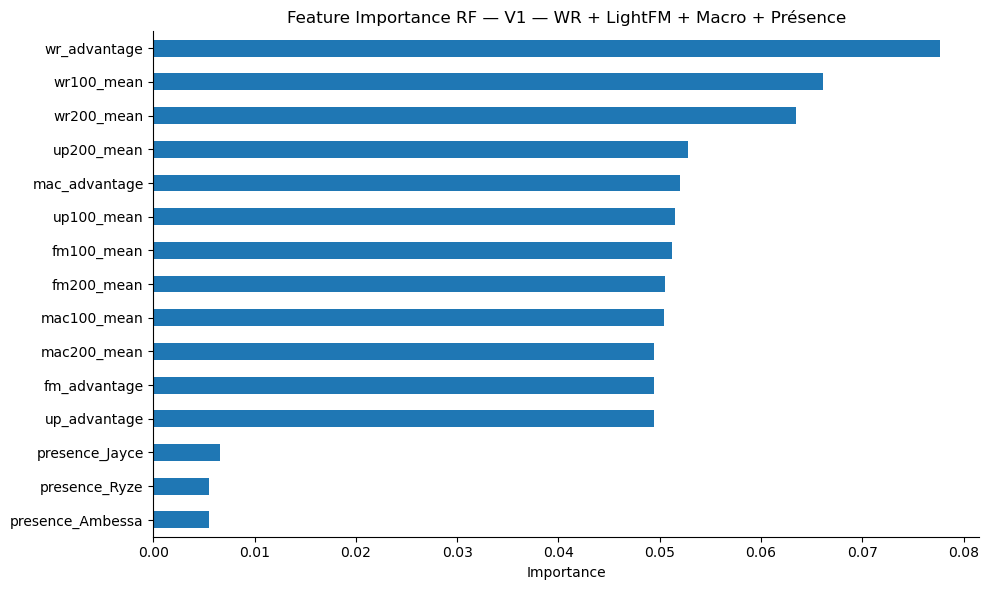

  → LDA AUC=0.5699 — mesure la séparabilité linéaire des features


In [30]:

# ═══════════════════════════════════════════════════════════════
# V1 — WR + LightFM + Macro + Présence (sans syn/counter)
# ═══════════════════════════════════════════════════════════════
class DraftFE_v1(DraftFeatureEngineering):
    def _extract(self, c100, c200):
        c100 = [c for c in c100 if c in self.all_champions]
        c200 = [c for c in c200 if c in self.all_champions]
        if len(c100) < 2 or len(c200) < 2: return None
        wr100  = [self.champ_wr(c) for c in c100]
        wr200  = [self.champ_wr(c) for c in c200]
        fm100  = [self.fm_synergy(a,b)     for a,b in combinations(c100,2)]
        fm200  = [self.fm_synergy(a,b)     for a,b in combinations(c200,2)]
        up100  = [self.uplift_synergy(a,b) for a,b in combinations(c100,2)]
        up200  = [self.uplift_synergy(a,b) for a,b in combinations(c200,2)]
        mac100 = [self.macro_comp(a,b) for a,b in combinations(c100,2)]
        mac200 = [self.macro_comp(a,b) for a,b in combinations(c200,2)]
        feat   = [np.mean(wr100), np.mean(wr200), np.mean(wr100)-np.mean(wr200)]
        feat  += [np.mean(fm100), np.mean(fm200), np.mean(fm100)-np.mean(fm200)]
        feat  += [np.mean(up100), np.mean(up200), np.mean(up100)-np.mean(up200)]
        feat  += [np.mean(mac100), np.mean(mac200), np.mean(mac100)-np.mean(mac200)]
        presence = [0.0]*self.n_champs
        for c in c100:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] =  1.0
        for c in c200:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] = -1.0
        feat += presence
        return feat

fe_v1 = DraftFE_v1(min_games=MIN_GAMES_FOR_STATS, emb_win=emb_win, emb_pop=emb_pop,
                    lfm_item2id=lfm_item2id, champ_style_vec=champ_style_vec)
fe_v1.fit(train_df)
X_tr1, idx1 = fe_v1.transform(train_df); y_tr1 = train_df['win'].values[idx1]
X_te1, idx2 = fe_v1.transform(test_df);  y_te1 = test_df['win'].values[idx2]

champs_v1 = sorted(fe_v1.all_champions)
feat_names_v1 = (
    ['wr100_mean','wr200_mean','wr_advantage'] +
    ['fm100_mean','fm200_mean','fm_advantage'] +
    ['up100_mean','up200_mean','up_advantage'] +
    ['mac100_mean','mac200_mean','mac_advantage'] +
    [f'presence_{c}' for c in champs_v1]
)
all_results['V1_WR_LFM_Macro'] = run_models(X_tr1, y_tr1, X_te1, y_te1,
                                              'V1 — WR + LightFM + Macro + Présence',
                                              feat_names=feat_names_v1)


🔧 Calcul synergies / counters / win rates...
   ✅ 171 champions | 13,651 paires syn | 27,409 paires counter

────────────────────────────────────────────────────────────
  V2 — LightFM + Macro + Présence (sans WR)
────────────────────────────────────────────────────────────
  Random Forest             AUC=0.5354  (1.6s)
  Logistic Regression       AUC=0.5703  (0.1s)
  Ridge                     AUC=0.5704  (0.1s)
  MLP Large                 AUC=0.5268  (11.9s)
  Lasso                     AUC=0.5698  (0.4s)
  LDA                       AUC=0.5704  (0.2s)
  LR_L1_C0.05               AUC=0.5699  (0.3s)
  LR_L1_C0.1                AUC=0.5701  (0.3s)
  ElasticNet                AUC=0.5703  (1.1s)

  Top 15 features RF — V2 — LightFM + Macro + Présence (sans WR) :
    up100_mean                           6.27%
    mac100_mean                          6.22%
    fm100_mean                           6.17%
    up200_mean                           6.16%
    mac_advantage                        6.10

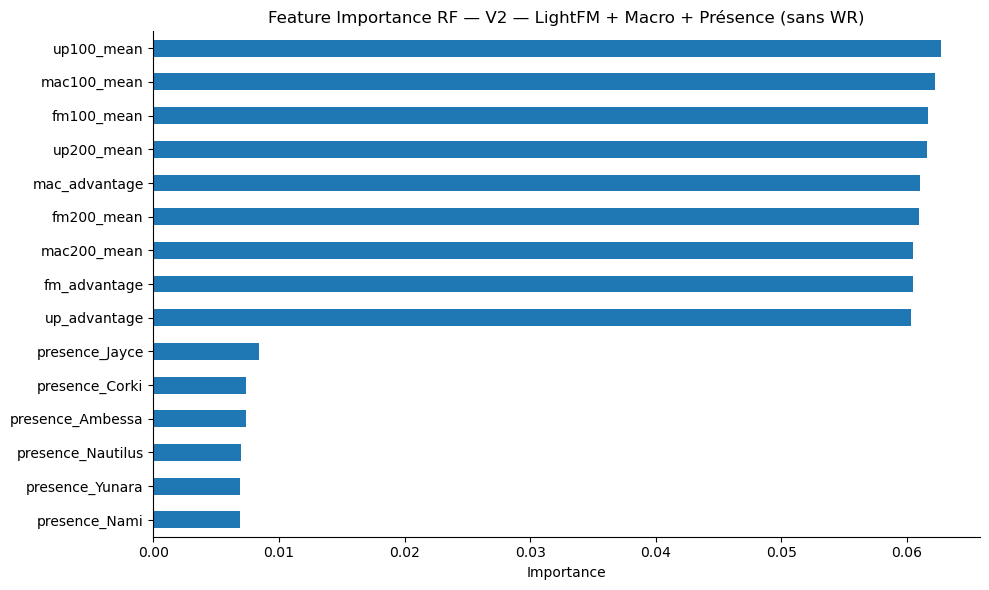

  → LDA AUC=0.5704 — mesure la séparabilité linéaire des features


In [31]:

# ═══════════════════════════════════════════════════════════════
# V2 — LightFM + Macro + Présence (sans WR, sans syn/counter)
# ═══════════════════════════════════════════════════════════════
class DraftFE_v2(DraftFeatureEngineering):
    def _extract(self, c100, c200):
        c100 = [c for c in c100 if c in self.all_champions]
        c200 = [c for c in c200 if c in self.all_champions]
        if len(c100) < 2 or len(c200) < 2: return None
        fm100  = [self.fm_synergy(a,b)     for a,b in combinations(c100,2)]
        fm200  = [self.fm_synergy(a,b)     for a,b in combinations(c200,2)]
        up100  = [self.uplift_synergy(a,b) for a,b in combinations(c100,2)]
        up200  = [self.uplift_synergy(a,b) for a,b in combinations(c200,2)]
        mac100 = [self.macro_comp(a,b) for a,b in combinations(c100,2)]
        mac200 = [self.macro_comp(a,b) for a,b in combinations(c200,2)]
        feat   = [np.mean(fm100), np.mean(fm200), np.mean(fm100)-np.mean(fm200)]
        feat  += [np.mean(up100), np.mean(up200), np.mean(up100)-np.mean(up200)]
        feat  += [np.mean(mac100), np.mean(mac200), np.mean(mac100)-np.mean(mac200)]
        presence = [0.0]*self.n_champs
        for c in c100:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] =  1.0
        for c in c200:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] = -1.0
        feat += presence
        return feat

fe_v2 = DraftFE_v2(min_games=MIN_GAMES_FOR_STATS, emb_win=emb_win, emb_pop=emb_pop,
                    lfm_item2id=lfm_item2id, champ_style_vec=champ_style_vec)
fe_v2.fit(train_df)
X_tr2, idx1 = fe_v2.transform(train_df); y_tr2 = train_df['win'].values[idx1]
X_te2, idx2 = fe_v2.transform(test_df);  y_te2 = test_df['win'].values[idx2]

champs_v2 = sorted(fe_v2.all_champions)
feat_names_v2 = (
    ['fm100_mean','fm200_mean','fm_advantage'] +
    ['up100_mean','up200_mean','up_advantage'] +
    ['mac100_mean','mac200_mean','mac_advantage'] +
    [f'presence_{c}' for c in champs_v2]
)
all_results['V2_LFM_Macro_nWR'] = run_models(X_tr2, y_tr2, X_te2, y_te2,
                                               'V2 — LightFM + Macro + Présence (sans WR)',
                                               feat_names=feat_names_v2)


🔧 Calcul synergies / counters / win rates...
   ✅ 171 champions | 13,651 paires syn | 27,409 paires counter

────────────────────────────────────────────────────────────
  V3 — WR + LightFM + Coverage fonctionnelle
────────────────────────────────────────────────────────────
  Random Forest             AUC=0.5519  (1.9s)
  Logistic Regression       AUC=0.5705  (0.2s)
  Ridge                     AUC=0.5705  (0.1s)
  MLP Large                 AUC=0.5532  (9.6s)
  Lasso                     AUC=0.5673  (2.1s)
  LDA                       AUC=0.5705  (0.2s)
  LR_L1_C0.05               AUC=0.5668  (0.4s)
  LR_L1_C0.1                AUC=0.5676  (1.0s)
  ElasticNet                AUC=0.5684  (3.7s)

  Top 15 features RF — V3 — WR + LightFM + Coverage fonctionnelle :
    wr_advantage                         4.15%
    wr100_mean                           3.69%
    wr200_mean                           3.29%
    cov_diff_siege                       2.69%
    up100_mean                           2.6

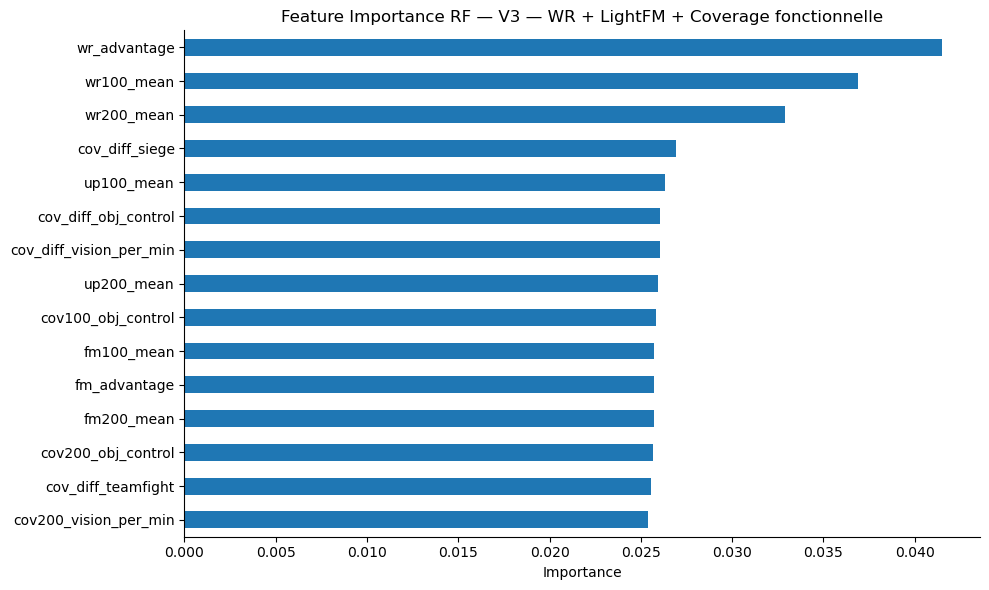

  → LDA AUC=0.5705 — mesure la séparabilité linéaire des features


In [32]:

# ═══════════════════════════════════════════════════════════════
# V3 — WR + LightFM + Coverage fonctionnelle + Présence
# Coverage = somme des valeurs POSITIVES par axe (négatif → 0)
# ═══════════════════════════════════════════════════════════════
class DraftFE_v3(DraftFeatureEngineering):

    def team_coverage_positive(self, team):
        sv = self.champ_style_vec
        if sv is None: return [0.0]*9
        axes = ['obj_control','siege','teamfight','frontline',
                'dps','cc_density','vision_per_min','early_pressure']
        available = [c for c in team if c in sv.index]
        if not available: return [0.0]*9
        # Somme des valeurs POSITIVES par axe (négatif → 0)
        coverage = []
        for axis in axes:
            vals = [max(0.0, float(sv.loc[c, axis])) for c in available]
            coverage.append(sum(vals))
        # Diversité : nombre d'axes avec au moins un champion > 0.3
        diversity = sum(1 for c in coverage if c > 0.3) / len(axes)
        return coverage + [diversity]

    def _extract(self, c100, c200):
        c100 = [c for c in c100 if c in self.all_champions]
        c200 = [c for c in c200 if c in self.all_champions]
        if len(c100) < 2 or len(c200) < 2: return None
        wr100  = [self.champ_wr(c) for c in c100]
        wr200  = [self.champ_wr(c) for c in c200]
        fm100  = [self.fm_synergy(a,b)     for a,b in combinations(c100,2)]
        fm200  = [self.fm_synergy(a,b)     for a,b in combinations(c200,2)]
        up100  = [self.uplift_synergy(a,b) for a,b in combinations(c100,2)]
        up200  = [self.uplift_synergy(a,b) for a,b in combinations(c200,2)]
        cov100 = self.team_coverage_positive(c100)
        cov200 = self.team_coverage_positive(c200)
        feat   = [np.mean(wr100), np.mean(wr200), np.mean(wr100)-np.mean(wr200)]
        feat  += [np.mean(fm100), np.mean(fm200), np.mean(fm100)-np.mean(fm200)]
        feat  += [np.mean(up100), np.mean(up200), np.mean(up100)-np.mean(up200)]
        feat  += cov100 + cov200
        feat  += [cov100[i]-cov200[i] for i in range(len(cov100))]
        presence = [0.0]*self.n_champs
        for c in c100:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] =  1.0
        for c in c200:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] = -1.0
        feat += presence
        return feat

fe_v3 = DraftFE_v3(min_games=MIN_GAMES_FOR_STATS, emb_win=emb_win, emb_pop=emb_pop,
                    lfm_item2id=lfm_item2id, champ_style_vec=champ_style_vec)
fe_v3.fit(train_df)
X_tr3, idx1 = fe_v3.transform(train_df); y_tr3 = train_df['win'].values[idx1]
X_te3, idx2 = fe_v3.transform(test_df);  y_te3 = test_df['win'].values[idx2]

axes_names = ['obj_control','siege','teamfight','frontline','dps','cc_density','vision_per_min','early_pressure','diversity']
champs_v3 = sorted(fe_v3.all_champions)
feat_names_v3 = (
    ['wr100_mean','wr200_mean','wr_advantage'] +
    ['fm100_mean','fm200_mean','fm_advantage'] +
    ['up100_mean','up200_mean','up_advantage'] +
    [f'cov100_{a}' for a in axes_names] +
    [f'cov200_{a}' for a in axes_names] +
    [f'cov_diff_{a}' for a in axes_names] +
    [f'presence_{c}' for c in champs_v3]
)
all_results['V3_WR_LFM_Coverage'] = run_models(X_tr3, y_tr3, X_te3, y_te3,
                                                 'V3 — WR + LightFM + Coverage fonctionnelle',
                                                 feat_names=feat_names_v3)


🔧 Calcul synergies / counters / win rates...
   ✅ 171 champions | 13,651 paires syn | 27,409 paires counter

────────────────────────────────────────────────────────────
  V4 — LightFM + Coverage fonctionnelle (sans WR)
────────────────────────────────────────────────────────────
  Random Forest             AUC=0.5125  (2.0s)
  Logistic Regression       AUC=0.5713  (0.1s)
  Ridge                     AUC=0.5714  (0.1s)
  MLP Large                 AUC=0.5282  (16.8s)
  Lasso                     AUC=0.5705  (0.8s)
  LDA                       AUC=0.5714  (0.2s)
  LR_L1_C0.05               AUC=0.5709  (0.4s)
  LR_L1_C0.1                AUC=0.5707  (0.7s)
  ElasticNet                AUC=0.5711  (3.0s)

  Top 15 features RF — V4 — LightFM + Coverage fonctionnelle (sans WR) :
    cov_diff_obj_control                 3.01%
    cov100_obj_control                   2.97%
    cov_diff_vision_per_min              2.96%
    cov_diff_siege                       2.93%
    cov200_vision_per_min        

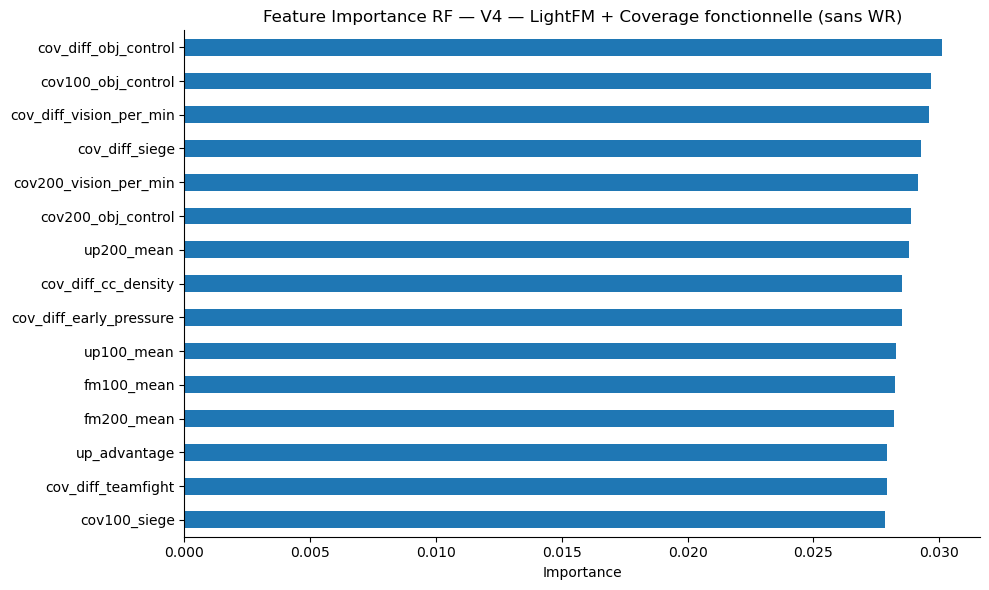

  → LDA AUC=0.5714 — mesure la séparabilité linéaire des features


In [33]:

# ═══════════════════════════════════════════════════════════════
# V4 — LightFM + Coverage fonctionnelle + Présence (sans WR)
# ═══════════════════════════════════════════════════════════════
class DraftFE_v4(DraftFE_v3):
    def _extract(self, c100, c200):
        c100 = [c for c in c100 if c in self.all_champions]
        c200 = [c for c in c200 if c in self.all_champions]
        if len(c100) < 2 or len(c200) < 2: return None
        fm100  = [self.fm_synergy(a,b)     for a,b in combinations(c100,2)]
        fm200  = [self.fm_synergy(a,b)     for a,b in combinations(c200,2)]
        up100  = [self.uplift_synergy(a,b) for a,b in combinations(c100,2)]
        up200  = [self.uplift_synergy(a,b) for a,b in combinations(c200,2)]
        cov100 = self.team_coverage_positive(c100)
        cov200 = self.team_coverage_positive(c200)
        feat   = [np.mean(fm100), np.mean(fm200), np.mean(fm100)-np.mean(fm200)]
        feat  += [np.mean(up100), np.mean(up200), np.mean(up100)-np.mean(up200)]
        feat  += cov100 + cov200
        feat  += [cov100[i]-cov200[i] for i in range(len(cov100))]
        presence = [0.0]*self.n_champs
        for c in c100:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] =  1.0
        for c in c200:
            if c in self.champion_to_idx: presence[self.champion_to_idx[c]] = -1.0
        feat += presence
        return feat

fe_v4 = DraftFE_v4(min_games=MIN_GAMES_FOR_STATS, emb_win=emb_win, emb_pop=emb_pop,
                    lfm_item2id=lfm_item2id, champ_style_vec=champ_style_vec)
fe_v4.fit(train_df)
X_tr4, idx1 = fe_v4.transform(train_df); y_tr4 = train_df['win'].values[idx1]
X_te4, idx2 = fe_v4.transform(test_df);  y_te4 = test_df['win'].values[idx2]

axes_names = ['obj_control','siege','teamfight','frontline','dps','cc_density','vision_per_min','early_pressure','diversity']
champs_v4 = sorted(fe_v4.all_champions)
feat_names_v4 = (
    ['fm100_mean','fm200_mean','fm_advantage'] +
    ['up100_mean','up200_mean','up_advantage'] +
    [f'cov100_{a}' for a in axes_names] +
    [f'cov200_{a}' for a in axes_names] +
    [f'cov_diff_{a}' for a in axes_names] +
    [f'presence_{c}' for c in champs_v4]
)
all_results['V4_LFM_Coverage_nWR'] = run_models(X_tr4, y_tr4, X_te4, y_te4,
                                                   'V4 — LightFM + Coverage fonctionnelle (sans WR)',
                                                   feat_names=feat_names_v4)


## 9. Résumé

In [38]:

# ── Résumé comparatif toutes versions x tous modèles ─────────────────────
versions = ['V1_WR_LFM_Macro','V2_LFM_Macro_nWR','V3_WR_LFM_Coverage','V4_LFM_Coverage_nWR']
all_models = sorted(set(m for v in all_results.values() for m in v.keys()))

print("\n" + "═"*80)
print(f"{'Modèle':<25}" + "".join(f"{'V'+str(i+1):>14}" for i in range(4)))
print("═"*80)
for model in all_models:
    row = f"{model:<25}"
    for v in versions:
        val = all_results.get(v,{}).get(model, float('nan'))
        auc = val['auc'] if isinstance(val, dict) else val
        row += f"{auc:>14.4f}" if auc == auc else f"{'—':>14}"
    print(row)
print("═"*80)

best_combo = max(
    ((v, m, val['auc'] if isinstance(val, dict) else val) 
     for v, res in all_results.items() for m, val in res.items()),
    key=lambda x: x[2]
)
print(f"\n🏆 Meilleure combinaison : {best_combo[0]} × {best_combo[1]} → AUC={best_combo[2]:.4f}")



════════════════════════════════════════════════════════════════════════════════
Modèle                               V1            V2            V3            V4
════════════════════════════════════════════════════════════════════════════════
ElasticNet                       0.5683        0.5703        0.5684        0.5711
LDA                              0.5699        0.5704        0.5705        0.5714
LR_L1_C0.05                      0.5663        0.5699        0.5668        0.5709
LR_L1_C0.1                       0.5673        0.5701        0.5676        0.5707
Lasso                            0.5672        0.5698        0.5673        0.5705
Logistic Regression              0.5699        0.5703        0.5705        0.5713
MLP Large                        0.5615        0.5268        0.5532        0.5282
Random Forest                    0.5551        0.5354        0.5519        0.5125
Ridge                            0.5699        0.5704        0.5705        0.5714
═════════════════

## 10. Interface de Prédiction

In [45]:
# Uniquement V4, modèles AUC > 0.57
results = {}
V4_THRESHOLD = 0.57

for model_name, val in all_results.get('V4_LFM_Coverage_nWR', {}).items():
    auc = val['auc'] if isinstance(val, dict) else val
    if auc >= V4_THRESHOLD:
        results[model_name] = val

best_name = max(results, key=lambda k: results[k]['auc'] if isinstance(results[k], dict) else results[k])
print(f"✅ {len(results)} modèles V4 retenus (AUC ≥ {V4_THRESHOLD})")
for name, val in sorted(results.items(), key=lambda x: -(x[1]['auc'] if isinstance(x[1], dict) else x[1])):
    auc = val['auc'] if isinstance(val, dict) else val
    print(f"   {name:<25} AUC={auc:.4f}")
print(f"\n🏆 Meilleur : {best_name}")

✅ 7 modèles V4 retenus (AUC ≥ 0.57)
   LDA                       AUC=0.5714
   Ridge                     AUC=0.5714
   Logistic Regression       AUC=0.5713
   ElasticNet                AUC=0.5711
   LR_L1_C0.05               AUC=0.5709
   LR_L1_C0.1                AUC=0.5707
   Lasso                     AUC=0.5705

🏆 Meilleur : LDA


In [46]:
def predict_winner(team_blue: list, team_red: list, verbose=True) -> dict:
    assert fe.fitted, "fe non fitté"
    feat = fe_v4._extract(team_blue, team_red)
    X    = np.array([feat], dtype=np.float32)

    probs_all = {}
    for n, res in results.items():
        m = res['model'] if isinstance(res, dict) else res
        if m is None:
            continue
        try:
            probs_all[n] = m.predict_proba(X)[0][1]
        except AttributeError:
            score = m.decision_function(X)[0]
            probs_all[n] = float(expit(score))

    best_prob  = probs_all[best_name]
    consensus  = np.mean(list(probs_all.values()))

    # Synergies pour visualisation
    syn_blue = {f"{a}&{b}": {
        'delta_wr': fe.synergy_wr(a, b),
        'uplift':   fe.uplift_synergy(a, b)
    } for a, b in combinations(team_blue, 2)}

    syn_red = {f"{a}&{b}": {
        'delta_wr': fe.synergy_wr(a, b),
        'uplift':   fe.uplift_synergy(a, b)
    } for a, b in combinations(team_red, 2)}

    if verbose:
        print(f"🔵 Blue  : {team_blue}")
        print(f"🔴 Red   : {team_red}")
        print(f"\n🏆 Meilleur modèle ({best_name}) : {best_prob:.1%} pour Blue")
        print(f"📊 Consensus ({len(probs_all)} modèles)  : {consensus:.1%} pour Blue")
        print("\nDétail par modèle :")
        for n, p in sorted(probs_all.items(), key=lambda x: -x[1]):
            print(f"  {n:<28} {p:.1%}")

    return {
        'win_prob_blue': best_prob,
        'win_prob_red':  1 - best_prob,
        'consensus':     consensus,
        'probs_all':     probs_all,
        'syn_blue':      syn_blue,
        'syn_red':       syn_red,
    }

In [47]:
def plot_prediction_enriched(result, team_blue, team_red):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    # 1. Prob bar
    pb, pr = result['win_prob_blue'], result['win_prob_red']
    axes[0].barh([''], [pb], color='#3498db', label=f'Bleue {pb:.1%}')
    axes[0].barh([''], [pr], left=[pb], color='#e74c3c', label=f'Rouge {pr:.1%}')
    axes[0].axvline(0.5, color='white', lw=2, ls='--')
    axes[0].set_xlim(0, 1); axes[0].set_title('Probabilité victoire')
    axes[0].legend(loc='lower right'); axes[0].set_yticks([])

    # 2. Model consensus
    mn = list(result['probs_all'].keys())
    mp = list(result['probs_all'].values())
    c  = ['#2ecc71' if p > 0.5 else '#e74c3c' for p in mp]
    axes[1].bar(range(len(mn)), mp, color=c)
    axes[1].axhline(0.5, ls='--', lw=1.5)
    axes[1].set_xticks(range(len(mn)))
    axes[1].set_xticklabels(mn, rotation=45, ha='right', fontsize=7)
    axes[1].set_ylim(0, 1); axes[1].set_title('Consensus modèles')
    for i, p in enumerate(mp):
        axes[1].text(i, p + 0.01, f'{p:.2f}', ha='center', fontsize=7)

    # 3. Delta WR synergies
    dwr_b = [v['delta_wr'] for v in result['syn_blue'].values()]
    dwr_r = [v['delta_wr'] for v in result['syn_red'].values()]
    x = np.arange(max(len(dwr_b), len(dwr_r)))
    axes[2].bar(x[:len(dwr_b)] - 0.2, dwr_b, 0.4, color='#3498db', alpha=0.8, label='Bleue')
    axes[2].bar(x[:len(dwr_r)] + 0.2, dwr_r, 0.4, color='#e74c3c', alpha=0.8, label='Rouge')
    axes[2].axhline(0, ls='--', lw=1); axes[2].set_title('Δwr synergies')
    axes[2].legend()

    # 4. Uplift LightFM
    up_b = [v['uplift'] for v in result['syn_blue'].values()]
    up_r = [v['uplift'] for v in result['syn_red'].values()]
    axes[3].bar(x[:len(up_b)] - 0.2, up_b, 0.4, color='#3498db', alpha=0.8, label='Bleue')
    axes[3].bar(x[:len(up_r)] + 0.2, up_r, 0.4, color='#e74c3c', alpha=0.8, label='Rouge')
    axes[3].axhline(0, ls='--', lw=1); axes[3].set_title('Uplift LightFM (win−pop)')
    axes[3].legend()

    plt.suptitle(f"{', '.join(team_blue)}  vs  {', '.join(team_red)}",
                 style='italic', fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

🔵 Blue  : ['Malphite', 'Vi', 'Orianna', 'Jinx', 'Thresh']
🔴 Red   : ['Jayce', 'Graves', 'Zed', 'Caitlyn', 'Karma']

🏆 Meilleur modèle (LDA) : 52.6% pour Blue
📊 Consensus (7 modèles)  : 58.9% pour Blue

Détail par modèle :
  Lasso                        99.5%
  Logistic Regression          52.6%
  LDA                          52.6%
  ElasticNet                   52.4%
  LR_L1_C0.1                   52.1%
  LR_L1_C0.05                  51.9%
  Ridge                        51.3%


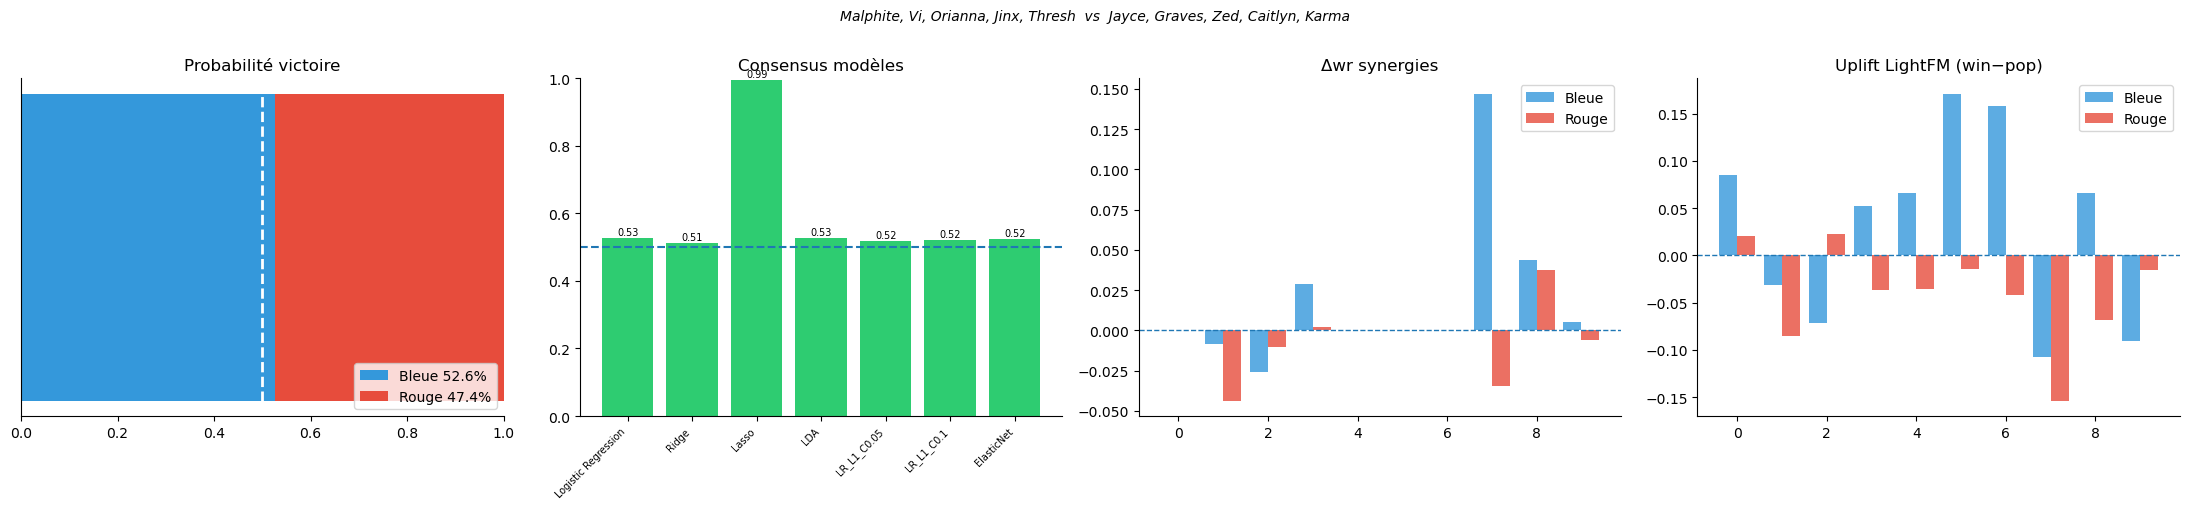

In [48]:
# Exemple de prédiction
result_demo = predict_winner(
    ["Malphite", "Vi", "Orianna", "Jinx", "Thresh"],
    ["Jayce", "Graves", "Zed", "Caitlyn", "Karma"]
)
plot_prediction_enriched(
    result_demo,
    ["Malphite", "Vi", "Orianna", "Jinx", "Thresh"],
    ["Jayce", "Graves", "Zed", "Caitlyn", "Karma"]
)

## 11. 🏆 Validation sur données pro 2026

On applique le meilleur modèle soloQ sur les games pro (Oracle's Elixir 2026, patches 16.01+16.02).
**Objectif** : mesurer si les patterns soloQ Master+ se généralisent au jeu professionnel.

In [49]:
import os, copy
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.calibration import calibration_curve

if not os.path.exists(PRO_CSV_PATH):
    print(f"⚠️  {PRO_CSV_PATH} non trouvé — place le fichier dans le même dossier")
else:
    print("📂 Chargement données pro...")
    df_pro_raw = pd.read_csv(PRO_CSV_PATH, low_memory=False)
    df_pro_raw.columns = df_pro_raw.columns.str.strip()
    if 'match_ids' in df_pro_raw.columns and 'match_id' not in df_pro_raw.columns:
        df_pro_raw = df_pro_raw.rename(columns={'match_ids': 'match_id'})

    CHAMP_NORM_PRO = {'KaiSa':'Kaisa', 'KhaZix':'Khazix', 'LeBlanc':'Leblanc'}
    df_pro_raw['championName'] = df_pro_raw['championName'].replace(CHAMP_NORM_PRO)

    games_pro = []
    for match_id, group in df_pro_raw.groupby('match_id'):
        t100 = group[group['teamId'] == 100]
        t200 = group[group['teamId'] == 200]
        if len(t100) != 5 or len(t200) != 5:
            continue
        games_pro.append({
            'match_id'      : match_id,
            'team100_champs': sorted(t100['championName'].tolist()),
            'team200_champs': sorted(t200['championName'].tolist()),
            'win'           : 1 if float(t100['win'].iloc[0]) == 1.0 else 0,
            'patch'         : str(t100['gameVersion'].iloc[0]) if 'gameVersion' in t100.columns else 'unknown',
        })

    games_pro_df = pd.DataFrame(games_pro)
    print(f"   {len(games_pro_df):,} games pro | Blue WR réel={games_pro_df['win'].mean():.1%}")

    # ── Prédiction par version x modèle ──────────────────────────────────────
    fe_map = {
        'V1_WR_LFM_Macro'    : fe_v1,
        'V2_LFM_Macro_nWR'   : fe_v2,
        'V3_WR_LFM_Coverage' : fe_v3,
        'V4_LFM_Coverage_nWR': fe_v4,
    }

    print(f"\n{'Version':<25} {'Modèle':<20} {'AUC soloQ':>10} {'AUC pro':>9} {'Acc pro':>8}")
    print("─" * 78)

    best_pro_auc = 0
    best_combo   = None
    pro_results  = {}

    for version_name, fe_v in fe_map.items():
        X_pro_v, idx_v = fe_v.transform(games_pro_df)
        y_pro_v = games_pro_df['win'].values[idx_v]
        if len(X_pro_v) < 10:
            print(f"  ⚠️  {version_name} : pas assez de games transformées ({len(X_pro_v)})")
            continue

        games_pro_eval = games_pro_df.iloc[idx_v].copy()
        pro_results[version_name] = {}

        for key, val in all_results.get(version_name, {}).items():
            auc_sq = val['auc'] if isinstance(val, dict) else val
            model  = val['model'] if isinstance(val, dict) else None
            if model is None or auc_sq < 0.57:
                continue

            if hasattr(model, 'predict_proba'):
                y_prob = model.predict_proba(X_pro_v)[:, 1]
            else:
                y_prob = expit(model.decision_function(X_pro_v))

            auc_pro = roc_auc_score(y_pro_v, y_prob)
            acc_pro = accuracy_score(y_pro_v, (y_prob > 0.5).astype(int))

            pro_results[version_name][key] = {
                'auc_soloq': auc_sq, 'auc_pro': auc_pro, 'acc_pro': acc_pro,
                'y_prob': y_prob, 'y_true': y_pro_v, 'idx': idx_v,
                'model': model, 'fe_v': fe_v
            }

            marker = ' ⭐' if auc_pro > best_pro_auc else ''
            print(f"  {version_name:<25} {key:<20} {auc_sq:>10.4f} {auc_pro:>9.4f} {acc_pro:>8.3f}{marker}")

            if auc_pro > best_pro_auc:
                best_pro_auc = auc_pro
                best_combo   = (version_name, key, model, fe_v, y_prob, y_pro_v, idx_v, games_pro_eval)

    print("─" * 78)
    if best_combo:
        print(f"\n🏆 Meilleur sur pro : {best_combo[0]} × {best_combo[1]} → AUC={best_pro_auc:.4f}")

📂 Chargement données pro...
   979 games pro | Blue WR réel=50.3%

Version                   Modèle                AUC soloQ   AUC pro  Acc pro
──────────────────────────────────────────────────────────────────────────────
  V2_LFM_Macro_nWR          Logistic Regression      0.5703    0.5486    0.533 ⭐
  V2_LFM_Macro_nWR          Ridge                    0.5704    0.5483    0.533
  V2_LFM_Macro_nWR          LDA                      0.5704    0.5483    0.533
  V2_LFM_Macro_nWR          LR_L1_C0.1               0.5701    0.5525    0.537 ⭐
  V2_LFM_Macro_nWR          ElasticNet               0.5703    0.5510    0.534
  V3_WR_LFM_Coverage        Logistic Regression      0.5705    0.5469    0.537
  V3_WR_LFM_Coverage        Ridge                    0.5705    0.5467    0.535
  V3_WR_LFM_Coverage        LDA                      0.5705    0.5467    0.535
  V4_LFM_Coverage_nWR       Logistic Regression      0.5713    0.5469    0.527
  V4_LFM_Coverage_nWR       Ridge                    0.5714   

### Analyse des prédictions pro

In [52]:
print('MonkeyKing' in fe_v4.all_champions)
print('Wukong' in fe_v4.all_champions)
print('Zaahen' in fe_v4.all_champions)

True
False
True


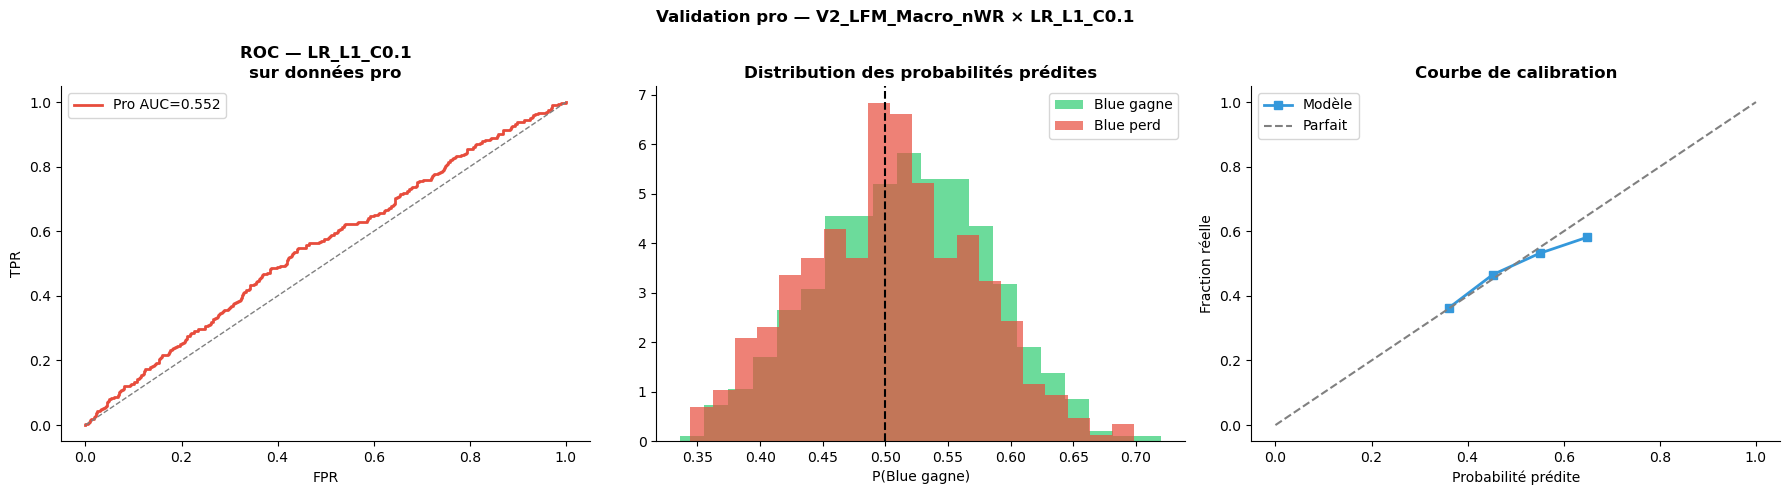


📊 Résultats globaux : 979 games
   Accuracy : 53.7%  |  AUC : 0.5525
   Blue WR réel   : 50.3%
   Blue WR prédit : 56.1%

   Accuracy par niveau de confiance :
     0-10% : 51.6% (498 games) ██████████
    10-20% : 54.6% (339 games) ██████████
    20-30% : 58.7% (126 games) ███████████
    30-40% : 60.0% (15 games) ████████████
    40-50% : 100.0% (1 games) ████████████████████

🔴 Top 10 erreurs les plus confiantes (upsets) :
  Prédit=Blue (69.9%) | Réel=Red | Confiance=39.7%
    Bleue : DrMundo, Lulu, Orianna, Sivir, Zaahen
    Rouge : Galio, Gnar, MonkeyKing, Senna, Zeri

  Prédit=Blue (69.6%) | Réel=Red | Confiance=39.2%
    Bleue : Aphelios, Jax, Jayce, Syndra, Thresh
    Rouge : Ashe, Aurora, Mel, Renekton, Vi

  Prédit=Blue (69.3%) | Réel=Red | Confiance=38.6%
    Bleue : Neeko, Orianna, Pantheon, Sivir, Zaahen
    Rouge : Azir, Karma, MonkeyKing, Sion, Varus

  Prédit=Blue (67.0%) | Réel=Red | Confiance=34.1%
    Bleue : Cassiopeia, Nautilus, Nocturne, Rumble, Sivir
    Rouge :

In [53]:
if 'best_combo' in dir() and best_combo is not None:
    v_name, m_name, best_m, best_fe_v, y_prob_pro, y_true_pro, idx_best, games_pro_eval = best_combo

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ROC
    fpr, tpr, _ = roc_curve(y_true_pro, y_prob_pro)
    axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Pro AUC={best_pro_auc:.3f}')
    axes[0].plot([0,1],[0,1],'--',color='grey',lw=1)
    axes[0].set_title(f'ROC — {m_name}\nsur données pro', fontweight='bold')
    axes[0].legend(); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

    # Distribution probabilités
    axes[1].hist(y_prob_pro[y_true_pro==1], bins=20, alpha=0.7, color='#2ecc71', label='Blue gagne', density=True)
    axes[1].hist(y_prob_pro[y_true_pro==0], bins=20, alpha=0.7, color='#e74c3c', label='Blue perd',  density=True)
    axes[1].axvline(0.5, ls='--', lw=1.5, color='black')
    axes[1].set_title('Distribution des probabilités prédites', fontweight='bold')
    axes[1].legend(); axes[1].set_xlabel('P(Blue gagne)')

    # Calibration
    frac_pos, mean_pred = calibration_curve(y_true_pro, y_prob_pro, n_bins=8)
    axes[2].plot(mean_pred, frac_pos, 's-', color='#3498db', lw=2, label='Modèle')
    axes[2].plot([0,1],[0,1],'--',color='grey', label='Parfait')
    axes[2].set_title('Courbe de calibration', fontweight='bold')
    axes[2].legend(); axes[2].set_xlabel('Probabilité prédite'); axes[2].set_ylabel('Fraction réelle')

    plt.suptitle(f'Validation pro — {v_name} × {m_name}', fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Tableau résultats game par game ──────────────────────────────────────
    games_pro_eval = games_pro_eval.copy().reset_index(drop=True)
    games_pro_eval['prob_blue']   = y_prob_pro
    games_pro_eval['prob_red']    = 1 - y_prob_pro
    games_pro_eval['pred_winner'] = np.where(y_prob_pro > 0.5, 'Blue', 'Red')
    games_pro_eval['real_winner'] = np.where(y_true_pro == 1, 'Blue', 'Red')
    games_pro_eval['correct']     = games_pro_eval['pred_winner'] == games_pro_eval['real_winner']
    games_pro_eval['confidence'] = np.abs(y_prob_pro - 0.5) * 2

    acc = games_pro_eval['correct'].mean()
    print(f"\n📊 Résultats globaux : {len(games_pro_eval):,} games")
    print(f"   Accuracy : {acc:.1%}  |  AUC : {best_pro_auc:.4f}")
    print(f"   Blue WR réel   : {games_pro_eval['real_winner'].eq('Blue').mean():.1%}")
    print(f"   Blue WR prédit : {games_pro_eval['pred_winner'].eq('Blue').mean():.1%}")

    # Accuracy par niveau de confiance
    bins   = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0]
    labels = ['0-10%','10-20%','20-30%','30-40%','40-50%','>50%']
    games_pro_eval['conf_bin'] = pd.cut(games_pro_eval['confidence'], bins=bins, labels=labels)
    conf_acc = games_pro_eval.groupby('conf_bin', observed=True)['correct'].agg(['mean','count'])
    print("\n   Accuracy par niveau de confiance :")
    for bin_label, row in conf_acc.iterrows():
        bar = '█' * int(row['mean'] * 20)
        print(f"   {bin_label:>7} : {row['mean']:.1%} ({row['count']:.0f} games) {bar}")

    # Top 10 upsets
    print("\n🔴 Top 10 erreurs les plus confiantes (upsets) :")
    errors_df = games_pro_eval[~games_pro_eval['correct']].sort_values('confidence', ascending=False).head(10)
    for _, row in errors_df.iterrows():
        print(f"  Prédit={row['pred_winner']} ({row['prob_red'] if row['pred_winner']=='Red' else row['prob_blue']:.1%}) | Réel={row['real_winner']} | Confiance={row['confidence']:.1%}")
        print(f"    Bleue : {', '.join(row['team100_champs'])}")
        print(f"    Rouge : {', '.join(row['team200_champs'])}")
        print()

    # Export CSV
    cols = ['match_id','team100_champs','team200_champs',
            'prob_blue','prob_red','pred_winner','real_winner','correct','confidence','patch']
    games_pro_eval[[c for c in cols if c in games_pro_eval.columns]].to_csv(
        'pro_predictions_v7.csv', index=False)
    print("💾 Prédictions exportées : pro_predictions_v7.csv")